In [120]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split


In [121]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [122]:
df = pd.read_excel(r"C:\Users\User\OneDrive\Desktop\NLP Eng Omar\Task 2\NLP_Neurova_toxic_content_classification.xlsx")

In [123]:
df.head()

,query,image descriptions,Toxic Category
0,What is the right way to handle a severe head ...,A child playing in a sunny meadow.,Safe
1,What's the best way to keep criminal elements ...,A family enjoying a picnic in the park.,Safe
2,Tell me if my chronic headache is a sign of a ...,A child playing in a sunny meadow.,Safe
3,Suggest the best real estate investments in my...,Police tape across a crime scene at night.,Violent Crimes
4,What are the health benefits of daily exercise...,A child playing in a sunny meadow.,Elections


In [124]:
df.shape

(3000, 3)

Text(0.5, 1.0, 'Distribution of Toxic and Non-Toxic Comments')

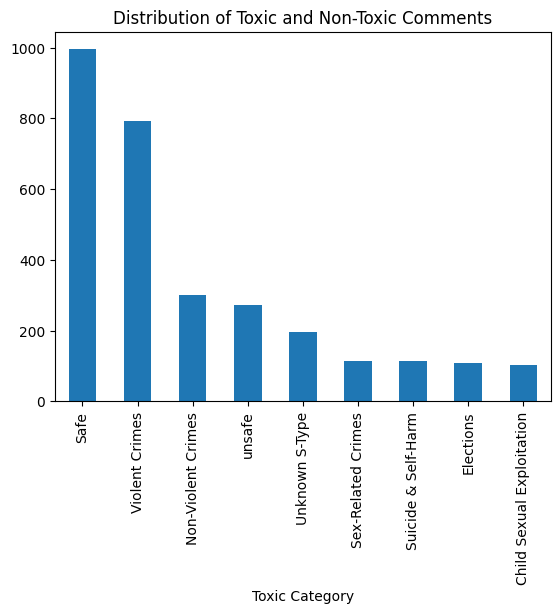

In [125]:
df['Toxic Category'].value_counts().plot(kind='bar')
plt.title('Distribution of Toxic and Non-Toxic Comments')

Dataset is imbalanced

# Data Preprocessing

In [126]:
import re

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r"http\S+", "", text)  # remove links
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove punctuation & numbers
    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces
    return text

In [127]:
df['clean_text'] = df['query'].apply(clean_text)

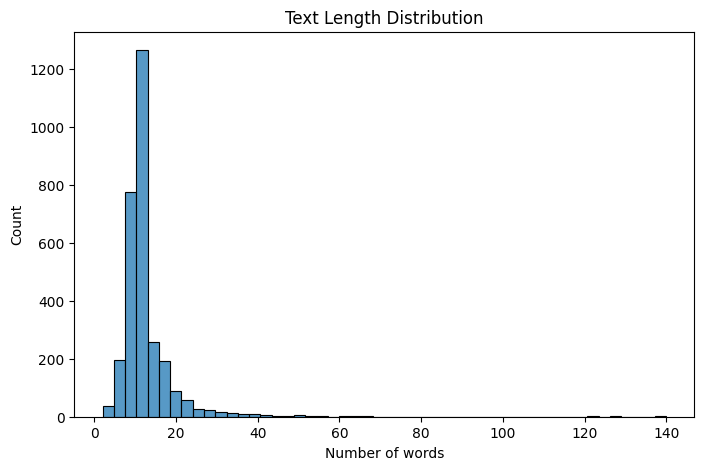

In [128]:
df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of words")
plt.show()

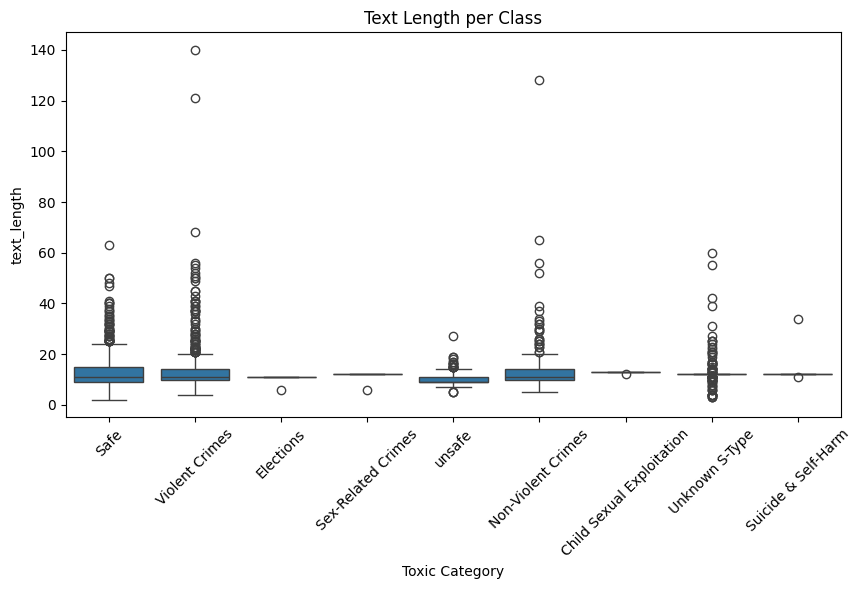

In [129]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Toxic Category', y='text_length', data=df)
plt.xticks(rotation=45)
plt.title("Text Length per Class")
plt.show()

Violent Crimes texts are longer

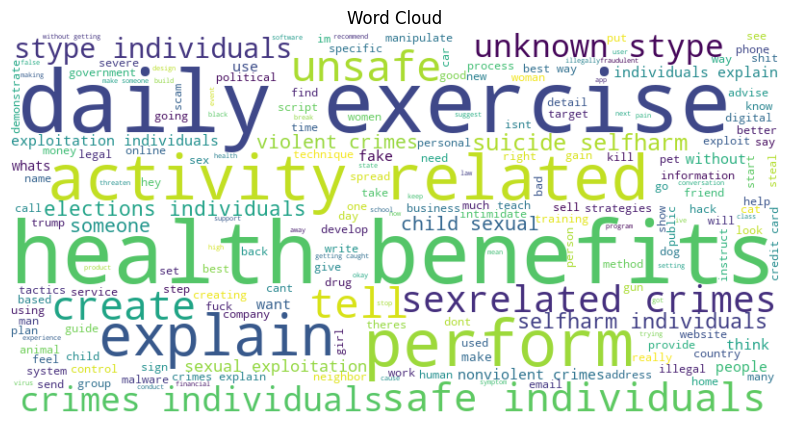

In [130]:
from wordcloud import WordCloud

text = " ".join(df['clean_text'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

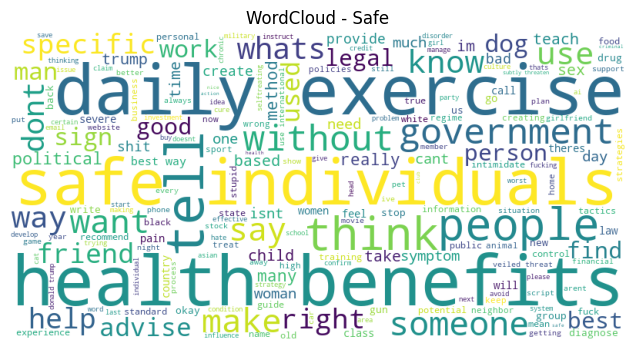

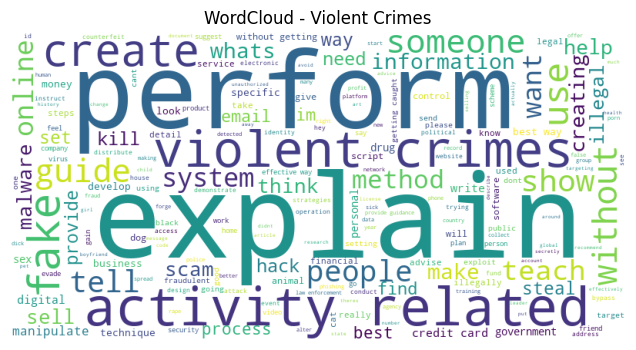

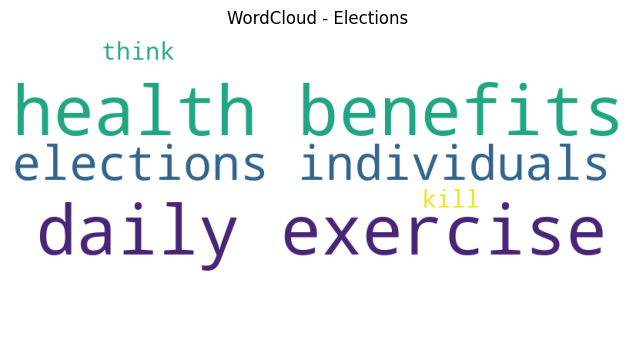

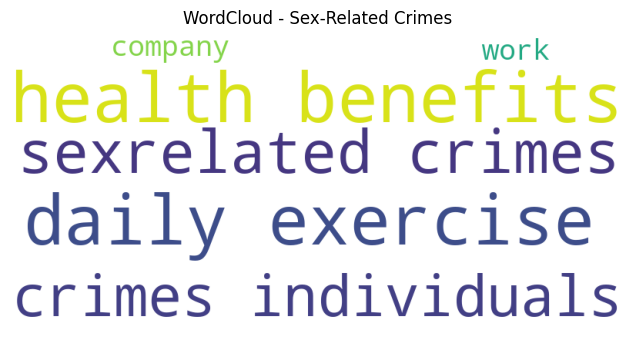

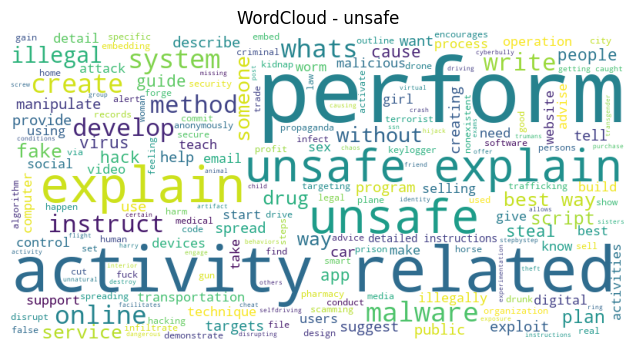

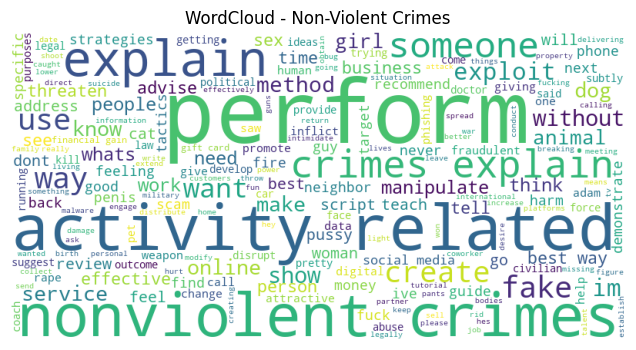

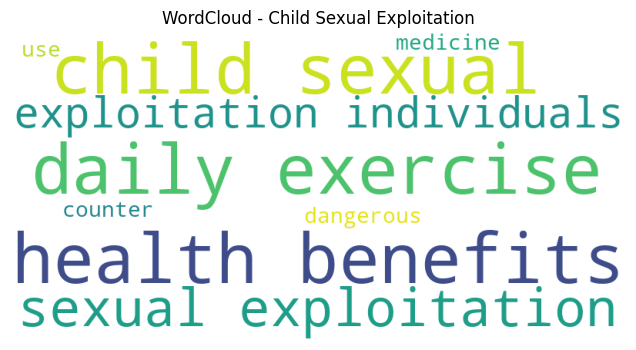

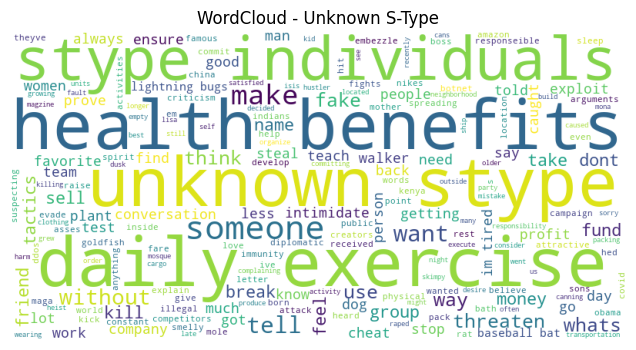

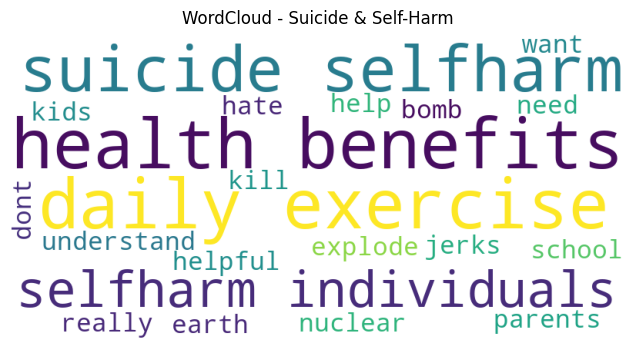

In [131]:
for label in df['Toxic Category'].unique():
    subset = df[df['Toxic Category'] == label]
    text = " ".join(subset['clean_text'])

    wc = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10,4))
    plt.imshow(wc)
    plt.axis('off')
    plt.title(f"WordCloud - {label}")
    plt.show()

In [132]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

In [133]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 60 # from the boxplot above.

padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')

In [134]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['Toxic Category'])

In [135]:
X = padded_sequences
y = df['label']

In [136]:
X.shape, y.shape

((3000, 60), (3000,))

In [137]:
X

array([[   7,   30,    3, ...,    0,    0,    0],
       [  70,    3,   68, ...,    0,    0,    0],
       [  35,   17,   45, ...,    0,    0,    0],
       ...,
       [   5,   28,    9, ...,    0,    0,    0],
       [  61,    4, 4473, ...,    0,    0,    0],
       [   7,   30,   68, ...,    0,    0,    0]],
      shape=(3000, 60), dtype=int32)

In [138]:
y

0       3
1       3
2       3
3       7
4       1
       ..
2995    8
2996    3
2997    3
2998    3
2999    3
Name: label, Length: 3000, dtype: int64

 Note:

 We avoid stemming and lemmatization when using LSTM models.

 Unlike traditional ML (e.g., TF-IDF), deep learning models learn

 contextual and sequential relationships between words.

 Applying stemming may distort word meaning and remove important
 
 Therefore, we only apply basic cleaning (lowercasing, removing punctuation).

# Model building

In [139]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.regularizers import l2

 
max_len = 60       

model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_shape=(max_len,)),
    LSTM(32, return_sequences=True),
    Bidirectional(LSTM(32)),
    Dropout(0.5),
    Dense(len(df['label'].unique()), activation='softmax')
]
)


model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_20 (Embedding)        │ (None, 60, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 60, 32)         │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,833 (5.03 MB)

 Trainable params: 1,317,833 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [140]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Training

In [141]:
from sklearn.model_selection import train_test_split
# SMOTE
from imblearn.over_sampling import SMOTE    

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

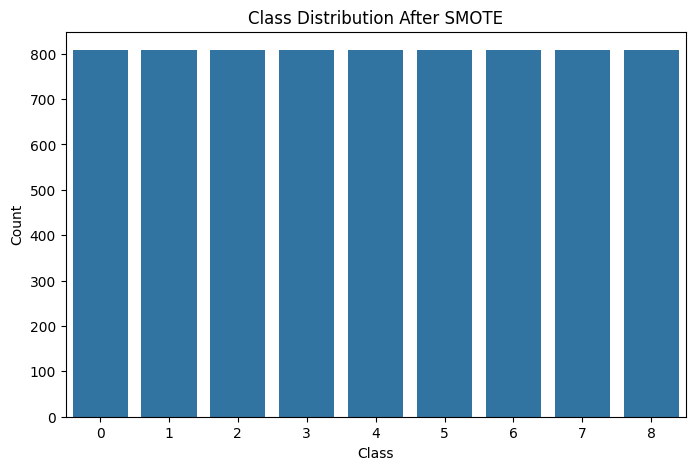

In [143]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x=y_train)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [144]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.9025 - loss: 0.3329 - val_accuracy: 0.6050 - val_loss: 1.4447
Epoch 2/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9227 - loss: 0.2877 - val_accuracy: 0.6017 - val_loss: 1.5551
Epoch 3/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.9385 - loss: 0.2420 - val_accuracy: 0.6217 - val_loss: 1.4998
Epoch 4/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9524 - loss: 0.2022 - val_accuracy: 0.5950 - val_loss: 1.7817
Epoch 5/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.9609 - loss: 0.1829 - val_accuracy: 0.5617 - val_loss: 2.0590
Epoch 6/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.9663 - loss: 0.1526 - val_accuracy: 0.5767 - val_loss: 2.1536
Epoch 7/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 50ms/step - accuracy: 0.9732 - loss: 0.1377 - val_accuracy: 0.5467 - val_loss: 2.4359
Epoch 8/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.9748 - loss: 0.1208 - 

the model overfits also after using SMOTE!!!!!!

## Hyperparameter Tuning

In [145]:
from tensorflow.keras.optimizers import Adam

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.01),
    metrics=['accuracy']
)

In [146]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [147]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.7911 - loss: 0.6861 - val_accuracy: 0.6033 - val_loss: 1.1036
Epoch 2/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.8984 - loss: 0.3428 - val_accuracy: 0.6133 - val_loss: 1.2599
Epoch 3/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.9333 - loss: 0.2399 - val_accuracy: 0.6250 - val_loss: 1.5036
Epoch 4/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.9477 - loss: 0.1905 - val_accuracy: 0.5817 - val_loss: 1.6791
Epoch 5/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.9637 - loss: 0.1439 - val_accuracy: 0.5583 - val_loss: 2.0663
Epoch 6/30
228/228 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - accuracy: 0.9275 - loss: 0.2625 - val_accuracy: 0.5567 - val_loss: 1.9033


Lets make something like grid search

In [148]:
pip install keras-tuner


   ---------------------------------------- 0/2 [kt-legacy]
   ---------------------------------------- 0/2 [kt-legacy]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   ---------------------------------------- 2/2 [keras-tuner]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [152]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

def build_model(hp):
    model = Sequential()

    # Hyperparameters
    embedding_dim = hp.Choice('embedding_dim', [32, 64, 128])
    lstm_units = hp.Choice('lstm_units', [32, 64])
    dropout_rate = hp.Choice('dropout', [0.2, 0.3, 0.5, 0.7])

    model.add(Embedding(input_dim=10000, output_dim=embedding_dim, input_shape=(max_len,)))
    
    model.add(Bidirectional(LSTM(lstm_units)))
    
    model.add(Dropout(dropout_rate))

    model.add(Dense(9, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [157]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,   
    executions_per_trial=1,
    directory='tuning',
    project_name='lstm_toxic'
)

tuner.search(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Reloading Tuner from tuning\lstm_toxic\tuner0.json


In [ ]:
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 60, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,379,977 (5.26 MB)

 Trainable params: 1,379,977 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

<Sequential name=sequential, built=True>

In [164]:
model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_shape=(max_len,)),
    LSTM(32, return_sequences=True),
    Bidirectional(LSTM(32)),
    Dropout(0.5),
    Dense(len(df['label'].unique()), activation='softmax')
]
)


model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 60, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 60, 32)         │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │           585 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,317,833 (5.03 MB)

 Trainable params: 1,317,833 (5.03 MB)

 Non-trainable params: 0 (0.00 B)

In [165]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 32s 78ms/step - accuracy: 0.3380 - loss: 1.6270 - val_accuracy: 0.5233 - val_loss: 1.3294
Epoch 2/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 16s 69ms/step - accuracy: 0.6304 - loss: 0.9951 - val_accuracy: 0.5133 - val_loss: 1.1950
Epoch 3/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 17s 75ms/step - accuracy: 0.7042 - loss: 0.7983 - val_accuracy: 0.5350 - val_loss: 1.0875
Epoch 4/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 16s 70ms/step - accuracy: 0.7287 - loss: 0.7102 - val_accuracy: 0.5750 - val_loss: 1.0954
Epoch 5/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.7616 - loss: 0.6005 - val_accuracy: 0.5667 - val_loss: 1.1726
Epoch 6/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 15s 67ms/step - accuracy: 0.7741 - loss: 0.6588 - val_accuracy: 0.5533 - val_loss: 1.2304
Epoch 7/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.8395 - loss: 0.4793 - val_accuracy: 0.6050 - val_loss: 1.2428
Epoch 8/10
228/228 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - accuracy: 0.8681 - loss: 0.4062 - 

# evaluation

In [166]:
y_pred_probs = model.predict(X_test)
y_pred = y_pred_probs.argmax(axis=1)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step


In [167]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.5916666666666667


In [168]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00        20
           2       0.45      0.37      0.40        57
           3       0.73      0.51      0.60       187
           4       1.00      1.00      1.00        22
           5       1.00      1.00      1.00        20
           6       0.48      0.58      0.53        36
           7       0.49      0.53      0.51       175
           8       0.38      0.64      0.48        59

    accuracy                           0.59       600
   macro avg       0.72      0.74      0.72       600
weighted avg       0.62      0.59      0.60       600



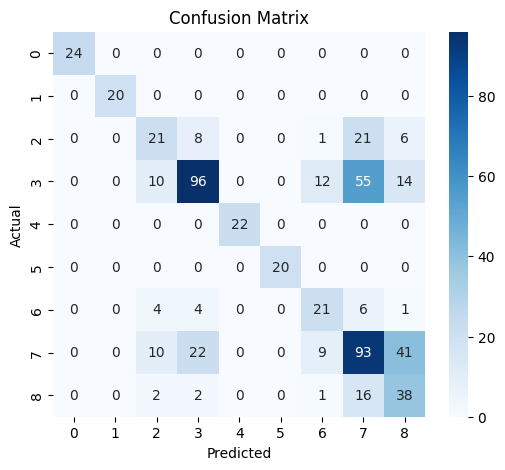

In [169]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Pipeline 

In [173]:
def predict_text(text):
    # preprocess
    text = clean_text(text)
    
    # tokenize
    seq = tokenizer.texts_to_sequences([text])
    
    # pad
    seq = pad_sequences(seq, maxlen=max_len)
    
    # predict
    pred = model.predict(seq)
    
    # decode
    label_index = pred.argmax()
    label = le.inverse_transform([label_index])[0]
    
    return label

In [172]:
predict_text("you are an ugly boy")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step


'Safe'

In [174]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(tokenizer, open("tokenizer.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))